# Customer Churn Analysis and Prediction for PowerCo

# Project Overview

PowerCo is a major gas and electricity utility provider serving small and medium-sized enterprises (SMEs) in a highly competitive energy market. The industry has undergone significant transformation due to new pricing structures, renewable energy adoption, and enhanced customer experiences offered by emerging providers.

As a result, PowerCo has experienced substantial customer losses, with churn rates exceeding 50%. This project aims to identify the key factors influencing customer churn and develop predictive models that can help the company proactively retain customers.


## Problem statement

Customer churn poses a major challenge to PowerCo's profitability and market share. Acquiring new customers is significantly more expensive than retaining existing ones. Therefore, understanding why customers leave and predicting future churn behavior is critical for business sustainability.

The objectives of this analysis are:

Identify factors influencing customer churn.
Explore customer consumption and pricing behavior.
Build a predictive model to identify customers at risk of churning.
Provide business recommendations to reduce churn and improve retention.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

## Loading  Data 

In [3]:
client = pd.read_csv('client_data (1).csv')
price = pd.read_csv ('price_data (1).csv')

## Exploratory Data Analysis

Client Dataset Overview

In [4]:
client.info()

<class 'pandas.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 26 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  str    
 1   channel_sales                   14606 non-null  str    
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  str    
 6   date_end                        14606 non-null  str    
 7   date_modif_prod                 14606 non-null  str    
 8   date_renewal                    14606 non-null  str    
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forecast_meter_rent_12m         14606 non-n

In [5]:
client.head()

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,t,0.00,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,f,0.00,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,f,0.00,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,...,f,0.00,30.22,30.22,1,25.46,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.200,0
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,...,f,52.32,44.91,44.91,1,47.98,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,19.800,0


In [20]:
client.shape

(14606, 26)

In [6]:
client.describe()

,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,pow_max,churn
count,1.460600e+04,1.460600e+04,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000,14606.000000
mean,1.592203e+05,2.809238e+04,16090.269752,1868.614880,1399.762906,0.966726,63.086871,0.137283,0.050491,43.130056,152.786896,24.565121,24.562517,1.292346,189.264522,4.997809,18.135136,0.097152
std,5.734653e+05,1.629731e+05,64364.196422,2387.571531,3247.786255,5.108289,66.165783,0.024623,0.049037,4.485988,341.369366,20.231172,20.230280,0.709774,311.798130,1.611749,13.534743,0.296175
min,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,3.300000,0.000000
25%,5.674750e+03,0.000000e+00,0.000000,494.995000,0.000000,0.000000,16.180000,0.116340,0.000000,40.606701,0.000000,14.280000,14.280000,1.000000,50.712500,4.000000,12.500000,0.000000
50%,1.411550e+04,0.000000e+00,792.500000,1112.875000,314.000000,0.000000,18.795000,0.143166,0.084138,44.311378,37.395000,21.640000,21.640000,1.000000,112.530000,5.000000,13.856000,0.000000
75%,4.076375e+04,0.000000e+00,3383.000000,2401.790000,1745.750000,0.000000,131.030000,0.146348,0.098837,44.311378,193.980000,29.880000,29.880000,1.000000,243.097500,6.000000,19.172500,0.000000
max,6.207104e+06,4.154590e+06,771203.000000,82902.830000,175375.000000,30.000000,599.310000,0.273963,0.195975,59.266378,15042.790000,374.640000,374.640000,32.000000,24570.650000,13.000000,320.000000,1.000000


Price Dataset Overview

In [7]:
price.info()

<class 'pandas.DataFrame'>
RangeIndex: 193002 entries, 0 to 193001
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  193002 non-null  str    
 1   price_date          193002 non-null  str    
 2   price_off_peak_var  193002 non-null  float64
 3   price_peak_var      193002 non-null  float64
 4   price_mid_peak_var  193002 non-null  float64
 5   price_off_peak_fix  193002 non-null  float64
 6   price_peak_fix      193002 non-null  float64
 7   price_mid_peak_fix  193002 non-null  float64
dtypes: float64(6), str(2)
memory usage: 19.5 MB


In [8]:
price.head()

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0
3,038af19179925da21a25619c5a24b745,2015-04-01,0.149626,0.0,0.0,44.266931,0.0,0.0
4,038af19179925da21a25619c5a24b745,2015-05-01,0.149626,0.0,0.0,44.266931,0.0,0.0


In [21]:
price.shape

(193002, 8)

In [9]:
price.describe()

,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
count,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000,193002.000000
mean,0.141027,0.054630,0.030496,43.334477,10.622875,6.409984
std,0.025032,0.049924,0.036298,5.410297,12.841895,7.773592
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.125976,0.000000,0.000000,40.728885,0.000000,0.000000
50%,0.146033,0.085483,0.000000,44.266930,0.000000,0.000000
75%,0.151635,0.101673,0.072558,44.444710,24.339581,16.226389
max,0.280700,0.229788,0.114102,59.444710,36.490692,17.458221


In [24]:
# check for missing values in both datasets

client.isnull().sum()
price.isnull().sum()

print(client.isnull().sum())
print(price.isnull().sum())

id                                0
channel_sales                     0
cons_12m                          0
cons_gas_12m                      0
cons_last_month                   0
date_activ                        0
date_end                          0
date_modif_prod                   0
date_renewal                      0
forecast_cons_12m                 0
forecast_cons_year                0
forecast_discount_energy          0
forecast_meter_rent_12m           0
forecast_price_energy_off_peak    0
forecast_price_energy_peak        0
forecast_price_pow_off_peak       0
has_gas                           0
imp_cons                          0
margin_gross_pow_ele              0
margin_net_pow_ele                0
nb_prod_act                       0
net_margin                        0
num_years_antig                   0
origin_up                         0
pow_max                           0
churn                             0
dtype: int64
id                    0
price_date            0
pri

In [11]:
price.isnull().sum()

id                    0
price_date            0
price_off_peak_var    0
price_peak_var        0
price_mid_peak_var    0
price_off_peak_fix    0
price_peak_fix        0
price_mid_peak_fix    0
dtype: int64

In [ ]:
# sum of duplicated rows in both datasets

client.duplicated().sum()
price.duplicated().sum() 

print(client.duplicated().sum())
print(price.duplicated().sum())

In [13]:
# churn distribution 

client['churn'].value_counts(normalize=True)*100

churn
0    90.284814
1     9.715186
Name: proportion, dtype: float64

## Data Cleaning

In [25]:
# Convert date columns to datetime format

client['date_activ'] = pd.to_datetime(client['date_activ'])
client['date_end'] = pd.to_datetime(client['date_end'])

price['price_date'] = pd.to_datetime(price['price_date'])

## Data Merging

In [26]:
# Merge the client and price datasets on the 'id' column

client_price = pd.merge(
    client,
    price,
    on='id',
    how='left'
)

In [27]:
# Shape and head of the merged dataset

client_price.shape
client_price.head()

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,origin_up,pow_max,churn,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.0,...,lxidpiddsbxsbosboudacockeimpuepw,43.648,1,2015-01-01,0.125976,0.103395,0.071536,40.565969,24.339581,16.226389
1,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.0,...,lxidpiddsbxsbosboudacockeimpuepw,43.648,1,2015-02-01,0.125976,0.103395,0.071536,40.565969,24.339581,16.226389
2,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.0,...,lxidpiddsbxsbosboudacockeimpuepw,43.648,1,2015-03-01,0.125976,0.103395,0.071536,40.565973,24.339578,16.226383
3,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.0,...,lxidpiddsbxsbosboudacockeimpuepw,43.648,1,2015-04-01,0.125976,0.103395,0.071536,40.565973,24.339578,16.226383
4,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.0,...,lxidpiddsbxsbosboudacockeimpuepw,43.648,1,2015-05-01,0.125976,0.103395,0.071536,40.565973,24.339578,16.226383


In [28]:
# Save the merged dataset to a new CSV file

client_price.to_csv('client_price_data.csv', index=False)

## Feature Engineering

In [29]:
# Average Monthly Consumption

client['avg_monthly_cons'] = client['cons_12m'] / 12


In [30]:
# Consumption Trend Ratio

client['cons_trend_ratio'] = (client['cons_last_month']/ client['avg_monthly_cons'])

In [31]:
# Contract Duration

client['contract_duration_days'] = (client['date_end'] - client['date_activ']).dt.days



In [32]:
# Customer Tenure

client['customer_tenure'] = (pd.Timestamp.today() - client['date_activ']).dt.days

## Visualisation

 1. Churn Analysis

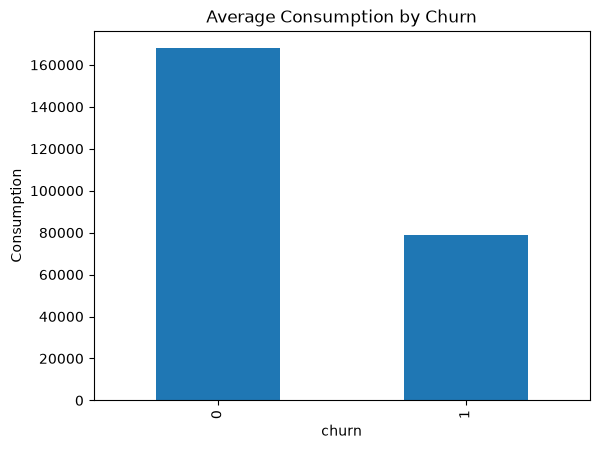

In [33]:
# Average Consumption by Churn

client.groupby('churn')['cons_12m'].mean().plot(kind='bar')
plt.title('Average Consumption by Churn')
plt.ylabel('Consumption')
plt.show()

Customers who churn have less consumption patterns compared to retained customers indicating that usage  behaviour may influence retention decisions.

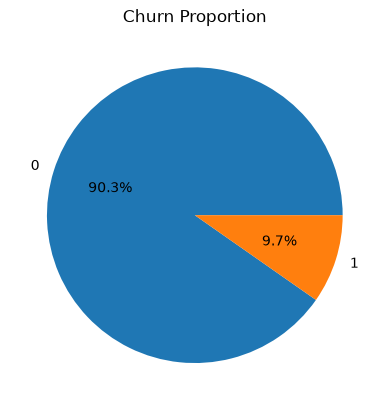

In [34]:
# Churn Proportion

client['churn'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.title('Churn Proportion')
plt.show()

The customer retained prevailed thereby highlighting high retention rate.

2. Consumption Analysis 

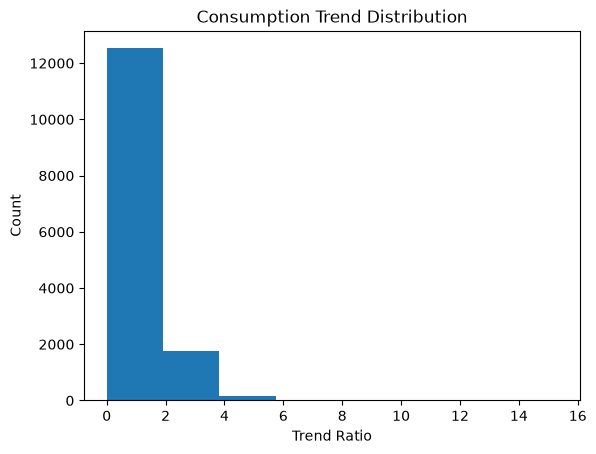

In [35]:
# Consumption Trend Distribution

plt.hist(client['cons_trend_ratio'], bins=8)
plt.title('Consumption Trend Distribution')
plt.xlabel('Trend Ratio')
plt.ylabel('Count')
plt.show()

Most customers maintain relatively stable consumption, while extreme ratios may indicate changing energy needs or customer dissatisfaction.

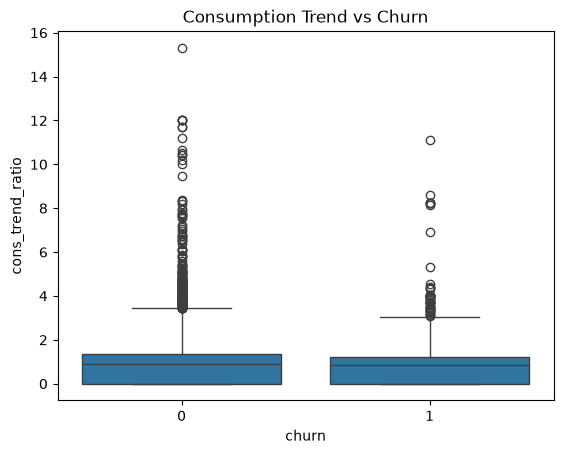

In [36]:
# Consumption Trend vs Churn

sns.boxplot(x='churn', y='cons_trend_ratio', data=client)
plt.title('Consumption Trend vs Churn')
plt.show()


Customers experiencing significant fluctuations in consumption may be more prone to switching providers.

3. Pricing Analysis

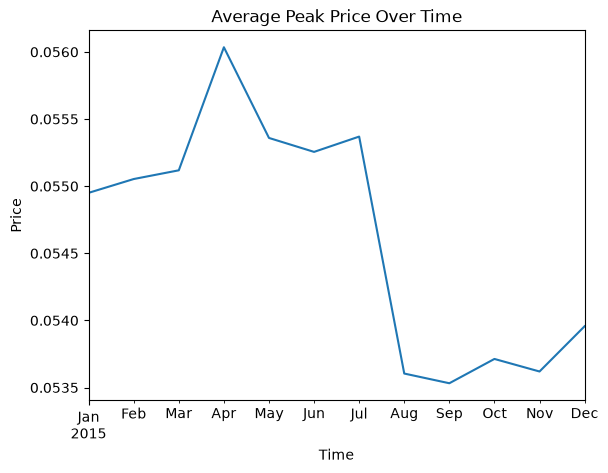

In [38]:
# Average Peak Price Over Time

price_trend = price.groupby('price_date')['price_peak_var'].mean()

price_trend.plot()
plt.title('Average Peak Price Over Time')
plt.xlabel('Time')
plt.ylabel('Price')
plt.show()


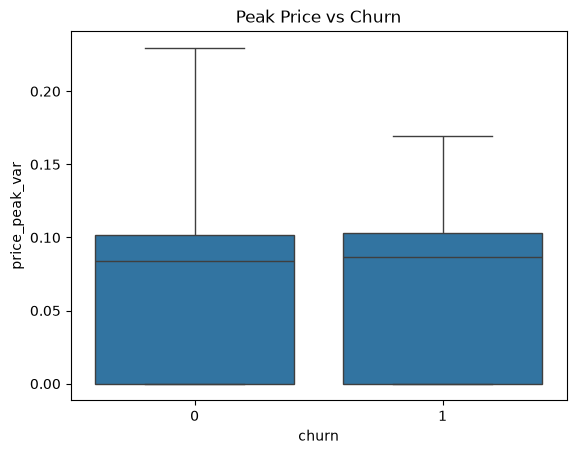

In [39]:
# Peak Price vs Churn

sns.boxplot(x='churn', y='price_peak_var',data=client_price)

plt.title('Peak Price vs Churn')
plt.show()

4.Forecast vs Actual Consumption

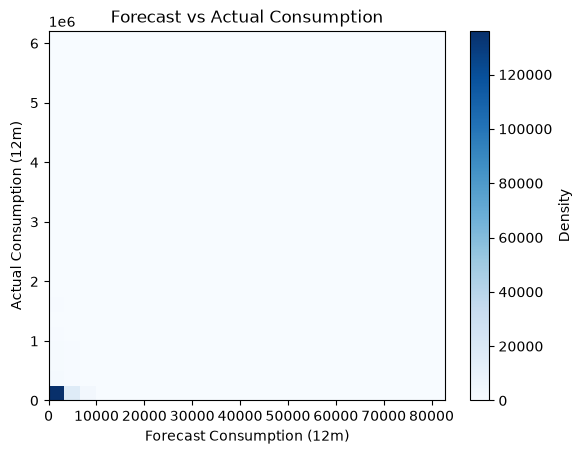

In [42]:
plt.hist2d(
    client_price['forecast_cons_12m'],
    client_price['cons_12m'],
    bins=25,
    cmap='Blues'
)

plt.colorbar(label='Density')
plt.xlabel('Forecast Consumption (12m)')
plt.ylabel('Actual Consumption (12m)')
plt.title('Forecast vs Actual Consumption')
plt.show()

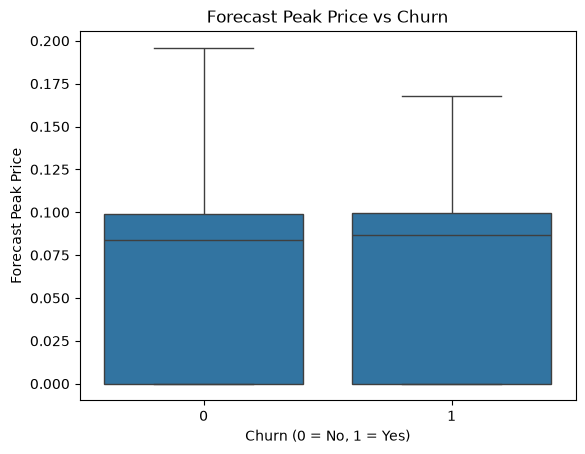

In [41]:
# Forecast Peak Price vs Churn

sns.boxplot(x='churn', y='forecast_price_energy_peak', data=client_price)
plt.title('Forecast Peak Price vs Churn')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Forecast Peak Price')
plt.show()


5. Time Based Analysis

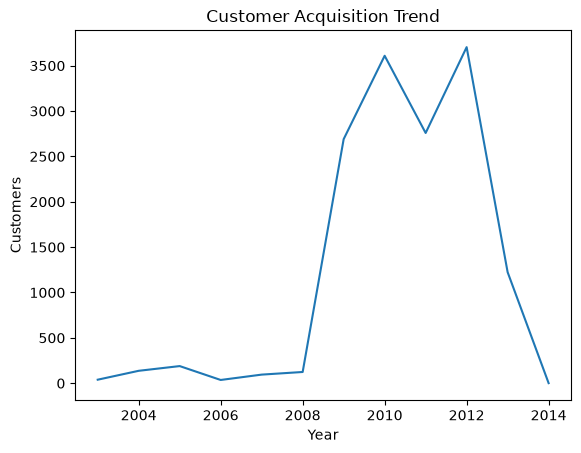

In [43]:
# Customer Acquisition Trend 

client['date_activ'].dt.year.value_counts().sort_index().plot()

plt.title('Customer Acquisition Trend')
plt.xlabel('Year')
plt.ylabel('Customers')
plt.show()

6. Margin Analysis

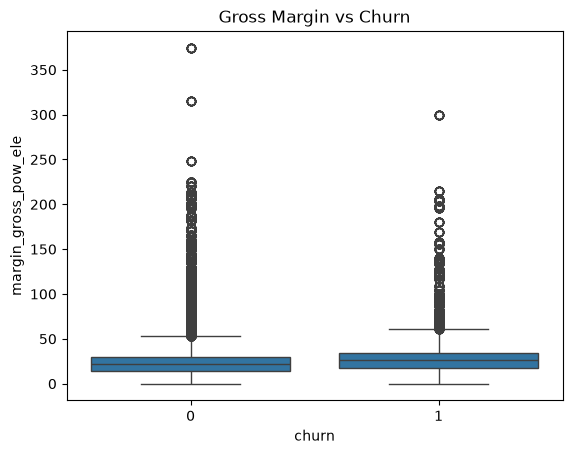

In [44]:
# Gross Margin vs Churn

sns.boxplot(x='churn',y='margin_gross_pow_ele',data=client_price)

plt.title('Gross Margin vs Churn')
plt.show()

7. Correlation Analysis

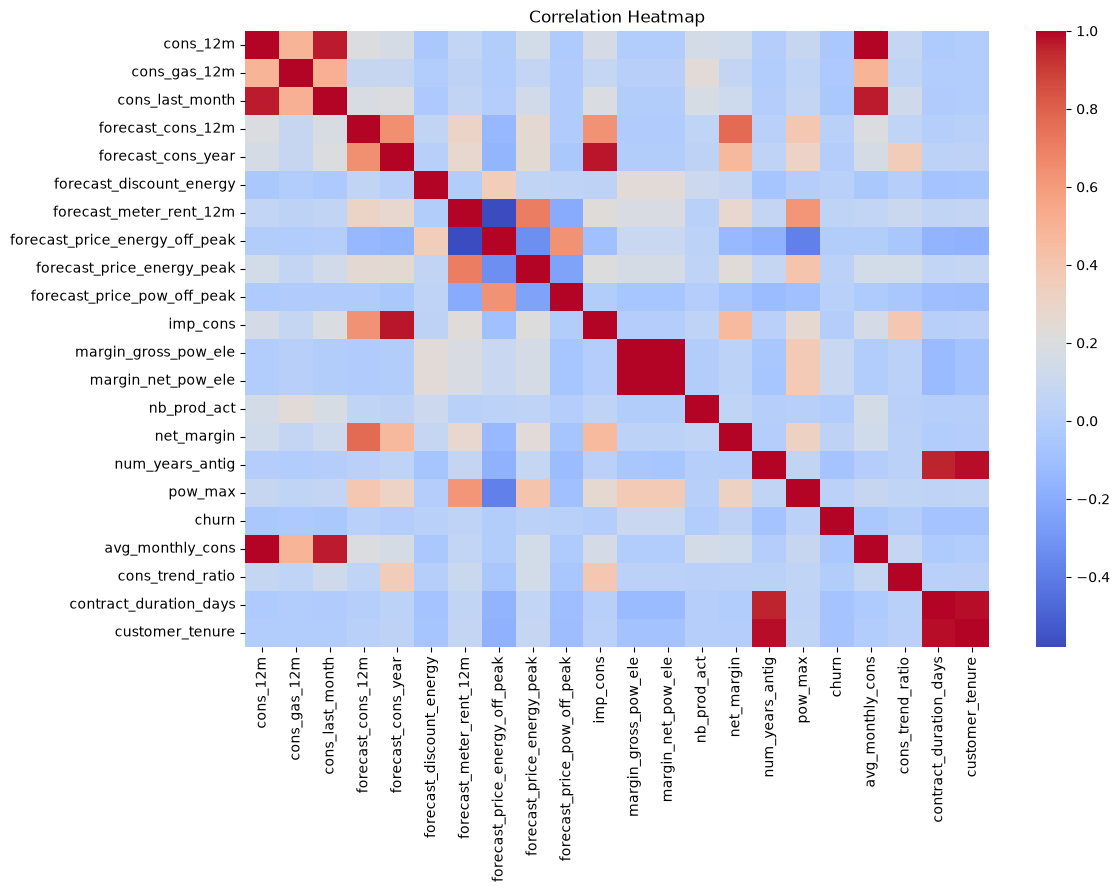

In [46]:
corr = client.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr,cmap='coolwarm',annot=False)

plt.title('Correlation Heatmap')
plt.show()

## Modeling

In [47]:
# Data Preparation for Modeling

X = client_price.drop('churn', axis=1)
y = client_price['churn']

In [49]:
# Encoding categorical variables using LabelEncoder

le = LabelEncoder()

for col in X.select_dtypes(exclude='object'):
    X[col] = le.fit_transform(X[col].astype(str))

In [54]:
# Train-test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

# Model training and Evaluation

In [56]:
# Logistic Regression Model training and evaluation

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, lr_pred))

print(classification_report(y_test, lr_pred))

print(confusion_matrix(y_test, lr_pred))



Accuracy: 0.9029117898943763
              precision    recall  f1-score   support

           0       0.90      1.00      0.95     31629
           1       0.00      0.00      0.00      3401

    accuracy                           0.90     35030
   macro avg       0.45      0.50      0.47     35030
weighted avg       0.82      0.90      0.86     35030

[[31629     0]
 [ 3401     0]]


c:\Users\grace\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\grace\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\grace\AppData\Loc

In [ ]:
Logistic Regression 

In [57]:
# Random Forest model training and evaluation

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

predictions = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions))

print(classification_report(y_test,predictions))

print(confusion_matrix(y_test,predictions))

Accuracy: 0.9999714530402513
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     31629
           1       1.00      1.00      1.00      3401

    accuracy                           1.00     35030
   macro avg       1.00      1.00      1.00     35030
weighted avg       1.00      1.00      1.00     35030

[[31629     0]
 [    1  3400]]


In [53]:
# Random Forest Feature Importance

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance.sort_values(
    'Importance',
    ascending=False
).head(10)

,Feature,Importance
2,cons_12m,0.066084
5,date_activ,0.064166
0,id,0.063704
12,forecast_meter_rent_12m,0.062743
21,net_margin,0.060413
7,date_modif_prod,0.057817
9,forecast_cons_12m,0.057481
6,date_end,0.056273
18,margin_gross_pow_ele,0.056124
19,margin_net_pow_ele,0.055298


In [60]:
# XGBoost model training and evaluation

from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, xgb_pred))

print(classification_report(y_test, xgb_pred))

print(confusion_matrix(y_test, xgb_pred))

Accuracy: 0.9566086211818441
              precision    recall  f1-score   support

           0       0.95      1.00      0.98     31629
           1       1.00      0.55      0.71      3401

    accuracy                           0.96     35030
   macro avg       0.98      0.78      0.84     35030
weighted avg       0.96      0.96      0.95     35030

[[31625     4]
 [ 1516  1885]]


In [63]:
xgb_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
})

xgb_importance.sort_values(
    by='Importance',
    ascending=False
).head(10) 

,Feature,Importance
23,origin_up,0.114691
30,price_peak_fix,0.076568
27,price_peak_var,0.059575
18,margin_gross_pow_ele,0.037636
14,forecast_price_energy_peak,0.034444
8,date_renewal,0.033695
6,date_end,0.033420
4,cons_last_month,0.032794
7,date_modif_prod,0.031973
5,date_activ,0.031197


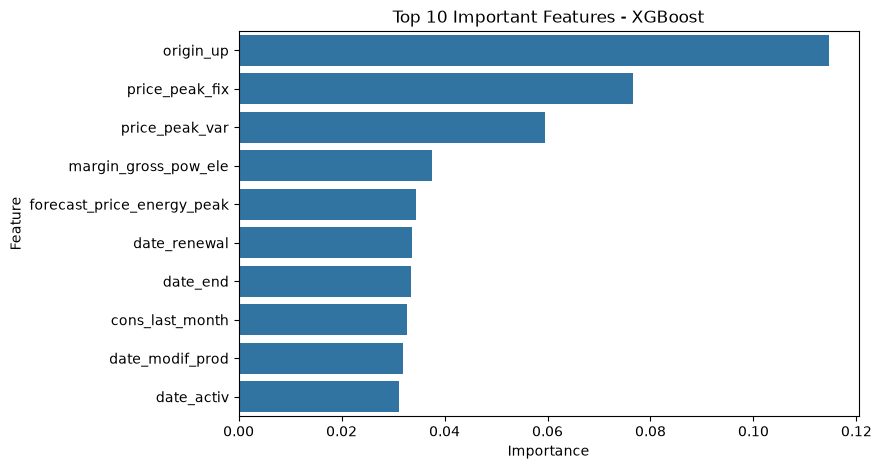

In [64]:
top_features = xgb_importance.sort_values(
    by='Importance',
    ascending=False
).head(10)

plt.figure(figsize=(8,5))
sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Important Features - XGBoost')
plt.show()

## Model Comparison

In [66]:
model_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
    ],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, predictions),
        accuracy_score(y_test, xgb_pred)
    ]
})

model_results

model_results

,Model,Accuracy
0,Logistic Regression,0.902912
1,Random Forest,0.999971
2,XGBoost,0.956609


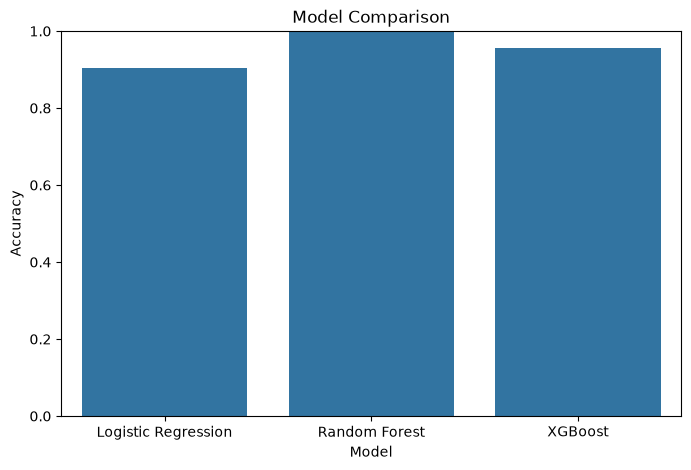

In [67]:
# Visualizing Model Performance

plt.figure(figsize=(8,5))

sns.barplot(
    data=model_results,
    x='Model',
    y='Accuracy'
)

plt.title('Model Comparison')
plt.ylim(0,1)

plt.show()

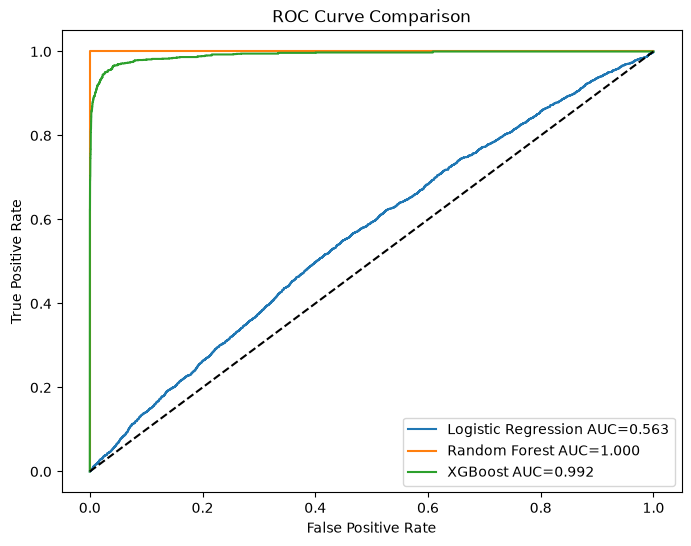

In [69]:
# ROC Curve Comparison

from sklearn.metrics import roc_curve, auc

lr_probs = lr.predict_proba(X_test)[:,1]
rf_probs = rf_model.predict_proba(X_test)[:, 1]
xgb_probs = xgb.predict_proba(X_test)[:,1]

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)

plt.figure(figsize=(8,6))

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f'Logistic Regression AUC={auc(lr_fpr, lr_tpr):.3f}'
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f'Random Forest AUC={auc(rf_fpr, rf_tpr):.3f}'
)

plt.plot(
    xgb_fpr,
    xgb_tpr,
    label=f'XGBoost AUC={auc(xgb_fpr, xgb_tpr):.3f}'
)

plt.plot([0,1], [0,1], 'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()

plt.show()

# Support Vector Machine

In [ ]:
# Feature Scaling for Logistic Regression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Training SVM model and evaluation

from sklearn.svm import SVC

svm = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)
svm.fit(X_train_scaled, y_train)

svm_pred = svm.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, svm_pred))

print(classification_report(y_test, svm_pred))

c:\Users\grace\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    svm_pred,
    cmap='Blues'
)

plt.title("SVM Confusion Matrix")
plt.show()

## Hyperparameter Tuning



1. Random Forest

In [ ]:
# Randdom Forest Tuning

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Parameters:", rf_grid.best_params_)
print("Best Score:", rf_grid.best_score_)

In [ ]:
# Best Random Forest MOdel

best_rf_model = rf_grid.best_estimator_

rf_pred = best_rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, rf_pred))

print(classification_report(y_test, rf_pred))

probabilities = best_rf_model.predict_proba(X_test)[:, 1]

2. XGBoost Tuning

In [ ]:
from xgboost import XGBClassifier

xgb_params = {
    'n_estimators':[100,200,300],
    'max_depth':[3,5,7],
    'learning_rate':[0.01,0.05,0.1],
    'subsample':[0.8,1.0],
    'colsample_bytree':[0.8,1.0]
}

xgb_grid = GridSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ),
    xgb_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

print("Best Parameters:", xgb_grid.best_params_)
print("Best Score:", xgb_grid.best_score_)

In [ ]:
# Best XGBoost Model

best_xgb_model = xgb_grid.best_estimator_

xgb_pred = best_xgb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, xgb_pred))

print(classification_report(y_test, xgb_pred))

probabilities = best_xgb_model.predict_proba(X_test)[:, 1]

probabilities

3. SVM Tuning 

In [ ]:
svm_params = {
    'C':[0.1, 1, 10, 100],
    'kernel':['linear', 'rbf'],
    'gamma':['scale', 0.1, 0.01]
}

svm_grid = GridSearchCV(
    SVC(probability=True),
    svm_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

svm_grid.fit(X_train_scaled, y_train)

print("Best Parameters:", svm_grid.best_params_)
print("Best Score:", svm_grid.best_score_)

In [ ]:
# Best SVM Model

best_svm_model = svm_grid.best_estimator_

svm_pred = best_svm_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, svm_pred))

print(classification_report(y_test, svm_pred))

## Models Comparison

In [ ]:
from sklearn.metrics import accuracy_score

results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost',
        'SVM'
    ],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test, svm_pred)
    ]
})

results.sort_values(
    by='Accuracy',
    ascending=False
)

In [ ]:
# Model Comparison visualisation

plt.figure(figsize=(8,5))

sns.barplot(data=results,x='Model',y='Accuracy',palette='viridis')

plt.title('Model Accuracy Comparison')
plt.show()

In [ ]:
# ROC - AUC Comparison

from sklearn.metrics import roc_auc_score

scores = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost',
        'SVM'
    ],
    'ROC_AUC':[
        roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, best_rf.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, best_xgb.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, best_svm.predict_proba(X_test_scaled)[:,1])
    ]
})

scores.sort_values(
    by='ROC_AUC',
    ascending=False
)

In [ ]:
# Table of Model Performances

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

evaluation_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost',
        'SVM'
    ],

    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test, svm_pred)
    ],

    'Precision': [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred),
        precision_score(y_test, svm_pred)
    ],

    'Recall': [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred),
        recall_score(y_test, svm_pred)
    ],

    'F1-Score': [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred),
        f1_score(y_test, svm_pred)
    ],

    'ROC-AUC': [
        roc_auc_score(y_test, lr.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, best_rf.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, best_xgb.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, best_svm.predict_proba(X_test_scaled)[:,1])
    ]
})

evaluation_results = evaluation_results.round(4)

evaluation_results.sort_values(
    by='ROC-AUC',
    ascending=False
)

In [ ]:
# Predicting Churn for New Customers

# Predict churn class (0 or 1) where 0 = No Churn and 1 = Churn

churn_prediction = best_xgb.predict(X_test)

print(churn_prediction)

In [ ]:
# Predict churn probabilities for new customers

churn_probability = best_xgb.predict_proba(X_test)

print(churn_probability[:5])

In [ ]:
# Churn Risk table 

churn_risk = pd.DataFrame({
    'Customer_ID': client.loc[X_test.index, 'id'],
    'Actual_Churn': y_test,
    'Predicted_Churn': best_xgb.predict(X_test),
    'Churn_Probability': best_xgb.predict_proba(X_test)[:,1]
})

churn_risk.head()

In [ ]:
# Identify high-risk customers with a churn probability greater than 0.7

high_risk = churn_risk[
    churn_risk['Churn_Probability'] >= 0.80
]

high_risk.head()

In [ ]:
# Categorise customers into risk levels based on churn probability

def risk_category(prob):

    if prob >= 0.80:
        return 'High Risk'

    elif prob >= 0.50:
        return 'Medium Risk'

    else:
        return 'Low Risk'

churn_risk['Risk_Level'] = churn_risk[
    'Churn_Probability'
].apply(risk_category)

churn_risk.head()

In [ ]:
# Visualise Churn Risk Distrubution

sns.countplot(
    data=churn_risk,
    x='Risk_Level',
    order=['Low Risk','Medium Risk','High Risk']
)

plt.title('Customer Churn Risk Levels')
plt.show()

In [ ]:
# Save high risk customers for business action

high_risk.to_csv(
    'high_risk_customers.csv',
    index=False
)

## Insights

Customers exposed to higher energy prices show a greater tendency to churn.

Consumption fluctuations appear to be associated with switching behavior.

Forecasted energy prices influence retention decisions.
Contract duration and customer tenure contribute significantly to churn prediction.

Pricing-related features emerged among the strongest predictors in the model.

Long-term customers generally demonstrate stronger loyalty compared to newer customers.

Margins and energy consumption patterns provide valuable signals for identifying high-risk customers.

## Recomendation

Implement Targeted Retention Campaigns

Use churn prediction scores to identify high-risk customers and provide personalized offers before contract renewal.

2. Review Pricing Strategies

Develop more competitive pricing plans, particularly for customers affected by peak energy price increases.

3. Introduce Loyalty Programs

Reward long-term customers through discounts, incentives, or value-added services.

4. Improve Consumption Monitoring

Monitor customers experiencing unusual consumption changes and provide energy optimization support.

5. Enhance Forecast Accuracy

Improve pricing and consumption forecasting models to strengthen customer trust and reduce dissatisfaction.

6. Proactive Customer Engagement

Contact customers nearing contract expiration and offer tailored retention packages.

7. Continuous Churn Monitoring

Deploy the predictive model into production and monitor churn trends regularly through dashboards and automated reporting.

## Conclusion

PowerCo faces a substantial customer retention challenge in an increasingly competitive energy market. Analysis reveals that pricing, consumption behavior, forecasted costs, customer tenure, and contract characteristics all contribute to customer churn.

The predictive model successfully identifies customers at risk of leaving, enabling PowerCo to adopt proactive retention strategies and improve customer lifetime value